In [1]:
import sys
import os

# Add the parent directory to Python's search path
sys.path.append(os.path.abspath('..'))

Evaluating Noiseless Baseline...
Evaluating Noisy Environment (p=0.08)...

✅ Graphic successfully saved to data/confusion_matrix.png


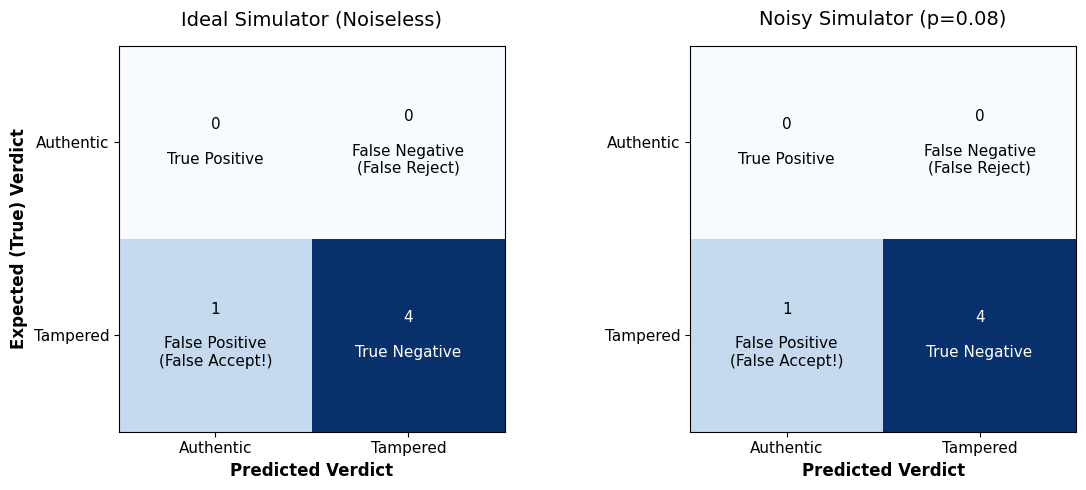

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from quantum_qr.evaluate import evaluate_corpus

# 1. Setup the Noise Model (Using the parameters from our Day 14 sweep)
# We choose a high enough noise level (p=0.08) to force some misclassifications 
# so the matrix isn't visually empty.
def get_noise_model(p: float) -> NoiseModel:
    error_1q = depolarizing_error(p, 1)
    error_2q = depolarizing_error(p, 2)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'rx', 'ry', 'rz', 'h', 'x'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    return noise_model

# 2. Initialize Backends
backend_clean = AerSimulator()
backend_noisy = AerSimulator(noise_model=get_noise_model(0.08))

# 3. Evaluate the Corpus
print("Evaluating Noiseless Baseline...")
results_clean = evaluate_corpus("../data/fixtures", backend=backend_clean)

print("Evaluating Noisy Environment (p=0.08)...")
results_noisy = evaluate_corpus("../data/fixtures", backend=backend_noisy)

# 4. Helper function to extract matrix counts
def get_matrix_counts(results):
    tp = sum(1 for r in results if r["expected_verdict"] == "authentic" and r["predicted_verdict"] == "authentic")
    fn = sum(1 for r in results if r["expected_verdict"] == "authentic" and r["predicted_verdict"] != "authentic")
    fp = sum(1 for r in results if r["expected_verdict"] == "tampered" and r["predicted_verdict"] == "authentic")
    tn = sum(1 for r in results if r["expected_verdict"] == "tampered" and r["predicted_verdict"] != "authentic")
    return np.array([[tp, fn], [fp, tn]])

# 5. Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
matrices = [get_matrix_counts(results_clean), get_matrix_counts(results_noisy)]
titles = ["Ideal Simulator (Noiseless)", "Noisy Simulator (p=0.08)"]

for idx, ax in enumerate(axes):
    mat = matrices[idx]
    cax = ax.imshow(mat, interpolation='nearest', cmap=plt.cm.Blues, vmin=0)
    
    classes = ['Authentic', 'Tampered']
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)
    
    ax.set_xlabel('Predicted Verdict', fontsize=12, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Expected (True) Verdict', fontsize=12, fontweight='bold')
    ax.set_title(titles[idx], fontsize=14, pad=15)
    
    labels = [['True Positive', 'False Negative\n(False Reject)'], 
              ['False Positive\n(False Accept!)', 'True Negative']]
              
    thresh = mat.max() / 2.
    for i in range(2):
        for j in range(2):
            color = "white" if mat[i, j] > thresh else "black"
            ax.text(j, i, f"{mat[i, j]}\n\n{labels[i][j]}", 
                    ha="center", va="center", color=color, fontsize=11)

plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=300, bbox_inches='tight')
print("\n✅ Graphic successfully saved to data/confusion_matrix.png")
plt.show()